In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from tqdm import tqdm

In [2]:
os.chdir("C:/Python/Datasets")
df = pd.read_csv("FMAC-HPI_24420.csv")
y = df['NSA Value']

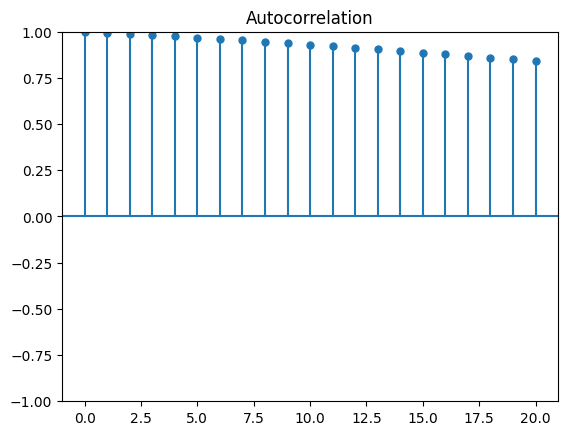

In [3]:
plot_acf(y, lags=20,alpha=None)
plt.show()

In [4]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]
y.shape, y_train.shape, y_test.shape

((531,), (519,), (12,))

#### AR Model

1st Order AR

In [7]:
model = ARIMA(y_train,order=(1,0,0))
model_fit = model.fit()
model_fit.params

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


const     101.667303
ar.L1       0.999910
sigma2      1.460148
dtype: float64

2nd Order AR

In [9]:
model = ARIMA(y_train,order=(2,0,0))
model_fit = model.fit()
model_fit.params

const     99.448481
ar.L1      1.945689
ar.L2     -0.945856
sigma2     0.165765
dtype: float64

In [10]:
y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
root_mean_squared_error(y_test, y_pred)

13.597351933209257

In [11]:
for i in [1,2,3,4]:
    model = ARIMA(y_train,order=(i,0,0))
    model_fit = model.fit()
    y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
    print(i, root_mean_squared_error(y_test, y_pred))

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


1 5.048069417113031
2 13.597351933209257


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


3 25.897291624996953
4 4.559154900250601


In [12]:
for i in [1,2,3,4]:
    model = ARIMA(y_train,order=(i,2,0))
    model_fit = model.fit()
    y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
    print(i, root_mean_squared_error(y_test, y_pred))

1 26.0250597825305
2 9.972607832169292
3 11.86339816288136
4 8.315482987552775


#### MA Model

1st order MA

In [15]:
model = ARIMA(y_train,order=(0,0,1))
model_fit = model.fit()
model_fit.params

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


const      99.474987
ma.L1       0.999547
sigma2    707.968492
dtype: float64

In [16]:
for i in [1,2,3,4]:
    model = ARIMA(y_train,order=(0,0,i))
    model_fit = model.fit()
    y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
    print(i, root_mean_squared_error(y_test, y_pred))

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


1 106.05185101450208
2 103.07903153370171


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


3 100.15591665702406


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


4 92.68309337422224


In [17]:
for i in [1,2,3,4]:
    model = ARIMA(y_train,order=(0,2,i))
    model_fit = model.fit()
    y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
    print(i, root_mean_squared_error(y_test, y_pred))

1 18.43462413294709


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2 14.750788852485238
3 13.061308024983608


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


4 13.442239809619538


#### ARMA

In [19]:
for i in [1,2,3,4]:
    for j in [1,2,3,4]:
        model = ARIMA(y_train,order=(i,0,j))
        model_fit = model.fit()
        y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
        print(i,j, root_mean_squared_error(y_test, y_pred))

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


1 1 3.692672589147763


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


1 2 2.639050533648944


C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


...

C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


4 2 3.50745888762174


C:\Python\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


4 3 8.401314851890852


LinAlgError: LU decomposition error.

#### ARIMA

In [ ]:
for i in [1,2,3,4]:
    for j in [1,2,3,4]:
        for k in [1,2,3]:
            model = ARIMA(y_train,order=(i,k,j))
            model_fit = model.fit()
            y_pred = model_fit.predict(start=len(y_train), end=len(y_train)+len(y_test)-1)
            print(i,j,k, root_mean_squared_error(y_test, y_pred))